# 🚦 YOLOv11 — Pelatihan Model Deteksi Kendaraan Lalu Lintas

---

| | |
|---|---|
| **Judul Skripsi** | Simulasi Sistem Pengendalian Lampu Lalu Lintas Berbasis YOLOv11 dan Logika Fuzzy untuk Prioritas Jalur di Persimpangan Kota |
| **Mahasiswa** | Mohammad Filla Firdaus |
| **NIM** | 2215354055 |
| **Program Studi** | Sarjana Terapan Teknologi Rekayasa Perangkat Lunak |
| **Institusi** | Politeknik Negeri Bali |
| **Tahun** | 2026 |
| **Dosen Pembimbing** | I Nyoman Eddy Indrayana, S.Kom., M.T. |

---

## 📋 Panduan Penggunaan Notebook

1. **Runtime** → **Change runtime type** → pilih **T4 GPU** (gratis)
2. Jalankan sel **secara berurutan dari atas ke bawah**
3. Setiap sel diberi label **[SEL-XX]** untuk kemudahan navigasi
4. Sel bertanda ⚙️ perlu **dikonfigurasi** sesuai dataset Anda

## 🗂️ Alur Notebook
```
[SEL-01] Cek GPU
[SEL-02] Install dependensi
[SEL-03] Mount Google Drive
[SEL-04] ⚙️ Konfigurasi path & hyperparameter
[SEL-05] Setup struktur folder
[SEL-06] Buat data.yaml
[SEL-07] Persiapan dataset (ekstrak frame / download)
[SEL-08] Split dataset 70:30
[SEL-09] Verifikasi & statistik dataset
[SEL-10] Load model YOLOv11
[SEL-11] 🚀 MULAI TRAINING
[SEL-12] Evaluasi model terbaik
[SEL-13] Confusion matrix & grafik
[SEL-14] Inferensi pada gambar/video uji
[SEL-15] Ekspor model (ONNX)
[SEL-16] Simpan ke Google Drive
```

---
## [SEL-01] 🖥️ Cek GPU & Lingkungan Runtime

In [62]:
# ──────────────────────────────────────────────────────────────
# [SEL-01] CEK GPU DAN LINGKUNGAN COLAB
# ──────────────────────────────────────────────────────────────
import subprocess, sys, os

print("=" * 55)
print("  CEK LINGKUNGAN GOOGLE COLAB")
print("=" * 55)

# Cek GPU
gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if gpu_info.returncode == 0:
    lines = gpu_info.stdout.split('\n')
    for line in lines[:15]:
        if line.strip():
            print(line)
    print("\n  [✓] GPU tersedia — Training akan berjalan dengan CUDA")
else:
    print("  [!] GPU tidak terdeteksi!")
    print("  → Pergi ke: Runtime → Change runtime type → T4 GPU")

# Cek Python
print(f"\n  Python  : {sys.version.split()[0]}")
print(f"  OS      : {os.uname().sysname} {os.uname().machine}")

# Cek RAM
mem = subprocess.run(['free', '-h'], capture_output=True, text=True)
if mem.returncode == 0:
    lines = mem.stdout.strip().split('\n')
    print(f"  RAM     : {lines[1].split()[1]} total")

# Cek disk
disk = subprocess.run(['df', '-h', '/'], capture_output=True, text=True)
if disk.returncode == 0:
    parts = disk.stdout.strip().split('\n')[1].split()
    print(f"  Disk    : {parts[3]} tersedia dari {parts[1]}")

  CEK LINGKUNGAN GOOGLE COLAB
Fri Jun 19 12:07:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             32W /   70W |    4889MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------

---
## [SEL-02] 📦 Install Dependensi

In [63]:
# ──────────────────────────────────────────────────────────────
# [SEL-02] INSTALL SEMUA DEPENDENSI YANG DIPERLUKAN
# ──────────────────────────────────────────────────────────────
print("[*] Menginstall dependensi...")
print("    (proses ini ~1-2 menit, hanya sekali per sesi)\n")

# Install Ultralytics (YOLOv11)
!pip install -q ultralytics

# Install dependensi tambahan
!pip install -q scikit-fuzzy matplotlib seaborn pandas pyyaml

# Verifikasi instalasi
print("\n[*] Verifikasi instalasi...")
import torch
import ultralytics
import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

print(f"  [✓] Ultralytics : v{ultralytics.__version__}")
print(f"  [✓] PyTorch     : v{torch.__version__}")
print(f"  [✓] CUDA        : {'tersedia (' + torch.version.cuda + ')' if torch.cuda.is_available() else 'tidak tersedia'}")
print(f"  [✓] OpenCV      : v{cv2.__version__}")
print(f"  [✓] NumPy       : v{np.__version__}")
print("\n  [✓] Semua dependensi berhasil diinstall!")

[*] Menginstall dependensi...
    (proses ini ~1-2 menit, hanya sekali per sesi)


[*] Verifikasi instalasi...
  [✓] Ultralytics : v8.4.71
  [✓] PyTorch     : v2.10.0+cu128
  [✓] CUDA        : tersedia (12.8)
  [✓] OpenCV      : v4.13.0
  [✓] NumPy       : v2.4.6

  [✓] Semua dependensi berhasil diinstall!


---
## [SEL-03] 📂 Mount Google Drive

In [64]:
# ──────────────────────────────────────────────────────────────
# [SEL-03] MOUNT GOOGLE DRIVE (HANYA JIKA DI GOOGLE COLAB)
# Hasil training akan disimpan permanen di Google Drive (Colab) 
# atau direktori output lokal (Kaggle/Lokal)
# ──────────────────────────────────────────────────────────────
import os

# Cek lingkungan secara presisi
IN_COLAB = os.path.exists('/var/colab/hostname')
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("\n  [✓] Google Drive berhasil di-mount di /content/drive")
    print("  [!] Semua hasil training akan disimpan di Google Drive")
    print("      agar tidak hilang saat sesi Colab berakhir.")
elif IN_KAGGLE:
    print("\n  [✓] Berjalan di lingkungan Kaggle.")
    print("  → Google Drive tidak perlu di-mount.")
    print("  → Semua hasil training akan disimpan di direktori output Kaggle (/kaggle/working).")
else:
    print("\n  [✓] Berjalan di lingkungan lokal / server mandiri.")
    print("  → Google Drive tidak perlu di-mount.")



  [✓] Berjalan di lingkungan Kaggle.
  → Google Drive tidak perlu di-mount.
  → Semua hasil training akan disimpan di direktori output Kaggle (/kaggle/working).


---
## [SEL-04] ⚙️ KONFIGURASI — Edit Bagian Ini!

In [65]:
# ==============================================================
# [SEL-04] KONFIGURASI UTAMA — SESUAIKAN DENGAN KEBUTUHAN
# Sesuai Tabel 3.7 Hyperparameter pada Proposal Skripsi
# (DIPERBAIKI: evaluasi mAP yang benar + training lebih sehat)
# ==============================================================

# -- Deteksi Lingkungan & Path Output --
import os
IN_COLAB = os.path.exists('/var/colab/hostname')
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

if IN_COLAB:
    DRIVE_PROJECT_DIR = "/content/drive/MyDrive/Skripsi_YOLOv11"
elif IN_KAGGLE:
    DRIVE_PROJECT_DIR = "/kaggle/working/Skripsi_YOLOv11"
else:
    DRIVE_PROJECT_DIR = "./Skripsi_YOLOv11"

DATASET_DIR = f"{DRIVE_PROJECT_DIR}/dataset"
RESULTS_DIR = f"{DRIVE_PROJECT_DIR}/runs"

# -- Konfigurasi Model --
# 'yolo11n.pt' | 'yolo11s.pt' | 'yolo11m.pt' (mAP lebih tinggi bila VRAM >=12GB) | 'yolo11l.pt'
MODEL_NAME = "yolo11s.pt"

# -- Hyperparameter Pelatihan (Tabel 3.7 Proposal) --
EPOCHS     = 100
BATCH_SIZE = 8       # 1x T4: batch 4 hanya pakai ~4.4G, jadi 8 aman & BN lebih stabil (437/8 sisa 5)
IMG_SIZE   = 960     # 960 menjaga objek kecil (sepeda motor) tetap terdeteksi
LR0        = 0.0005  # diturunkan: cegah NaN/Inf loss pada AdamW + full fine-tune
OPTIMIZER  = "AdamW"
PATIENCE   = 50      # Early stopping patience

EXPERIMENT_NAME = f"yolov11_traffic_ep{EPOCHS}_lr{LR0}_sz{IMG_SIZE}_fix"

from pathlib import Path
RUN_DIR = Path(RESULTS_DIR) / EXPERIMENT_NAME
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"

CLASS_NAMES = ["Mobil", "Motor", "Bus", "Truk"]
NUM_CLASSES = len(CLASS_NAMES)

TRAIN_RATIO = 0.70
RANDOM_SEED = 42

# -- Threshold --
# PENTING: bedakan dua hal:
#   VAL_CONF : dipakai saat MENGHITUNG mAP (HARUS kecil, 0.001) agar seluruh kurva
#              Precision-Recall ikut dihitung. Inilah perbaikan utama:
#              sebelumnya 0.50 -> recall Motor jatuh ke 0.01.
#   CONF_THRESHOLD : HANYA untuk INFERENSI/demo (GUI/video), BUKAN untuk mAP.
VAL_CONF       = 0.001
VAL_IOU        = 0.7
CONF_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.70

# -- Pilih GPU --
# CATATAN: multi-GPU (DDP "0,1") sering GAGAL di dalam notebook Kaggle
# (CalledProcessError dari torch.distributed.run). Maka default = 1 GPU saja,
# yang sudah lebih dari cukup untuk yolo11s. Satu T4 ~ aman.
import torch
_ngpu = torch.cuda.device_count() if torch.cuda.is_available() else 0
DEVICE = 0 if _ngpu >= 1 else "cpu"
# (Opsional, kalau benar2 mau coba 2 GPU: set manual  DEVICE = "0,1" )

print("=" * 55)
print("  KONFIGURASI PELATIHAN YOLOv11 (FIXED - proper mAP eval)")
print("  Skripsi: Mohammad Filla Firdaus | NIM. 2215354055")
print("=" * 55)
print(f"  Model          : {MODEL_NAME}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Image Size     : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Learning Rate  : {LR0}")
print(f"  Optimizer      : {OPTIMIZER}")
print(f"  Early Stopping : patience={PATIENCE}")
print(f"  GPU terdeteksi : {_ngpu}  ->  device={DEVICE}")
print(f"  Eval conf (mAP): {VAL_CONF}  (BUKAN 0.50!)")
print(f"  Kelas          : {CLASS_NAMES}")
print(f"  Eksperimen     : {EXPERIMENT_NAME}")
print("=" * 55)


  KONFIGURASI PELATIHAN YOLOv11 (FIXED - proper mAP eval)
  Skripsi: Mohammad Filla Firdaus | NIM. 2215354055
  Model          : yolo11s.pt
  Epochs         : 100
  Batch Size     : 8
  Image Size     : 960x960
  Learning Rate  : 0.0005
  Optimizer      : AdamW
  Early Stopping : patience=50
  GPU terdeteksi : 2  ->  device=0
  Eval conf (mAP): 0.001  (BUKAN 0.50!)
  Kelas          : ['Mobil', 'Motor', 'Bus', 'Truk']
  Eksperimen     : yolov11_traffic_ep100_lr0.0005_sz960_fix


---
## [SEL-05] 📁 Setup Struktur Folder

In [66]:
# ──────────────────────────────────────────────────────────────
# [SEL-05] BUAT STRUKTUR FOLDER PROYEK
# ──────────────────────────────────────────────────────────────
import os
from pathlib import Path

# Folder yang diperlukan
folders = [
    DRIVE_PROJECT_DIR,
    f"{DATASET_DIR}/images/train",
    f"{DATASET_DIR}/images/val",
    f"{DATASET_DIR}/images/test",
    f"{DATASET_DIR}/labels/train",
    f"{DATASET_DIR}/labels/val",
    f"{DATASET_DIR}/labels/test",
    RESULTS_DIR,
    f"{DRIVE_PROJECT_DIR}/exports",
    f"{DRIVE_PROJECT_DIR}/logs",
    "/content/dataset",     # Folder kerja lokal (lebih cepat saat training)
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("  [✓] Struktur folder berhasil dibuat:")
print(f"""
  📁 {DRIVE_PROJECT_DIR}/
  ├── 📁 dataset/
  │   ├── 📁 images/
  │   │   ├── 📁 train/   ← Upload 70% gambar ke sini
  │   │   ├── 📁 val/     ← Upload 30% gambar ke sini
  │   │   └── 📁 test/    ← Gambar uji opsional
  │   └── 📁 labels/
  │       ├── 📁 train/   ← Label .txt YOLO format
  │       ├── 📁 val/
  │       └── 📁 test/
  ├── 📁 runs/             ← Hasil training otomatis tersimpan
  ├── 📁 exports/          ← Model .onnx hasil ekspor
  └── 📁 logs/             ← Log training
  """)

  [✓] Struktur folder berhasil dibuat:

  📁 /kaggle/working/Skripsi_YOLOv11/
  ├── 📁 dataset/
  │   ├── 📁 images/
  │   │   ├── 📁 train/   ← Upload 70% gambar ke sini
  │   │   ├── 📁 val/     ← Upload 30% gambar ke sini
  │   │   └── 📁 test/    ← Gambar uji opsional
  │   └── 📁 labels/
  │       ├── 📁 train/   ← Label .txt YOLO format
  │       ├── 📁 val/
  │       └── 📁 test/
  ├── 📁 runs/             ← Hasil training otomatis tersimpan
  ├── 📁 exports/          ← Model .onnx hasil ekspor
  └── 📁 logs/             ← Log training
  


---
## [SEL-06] 📝 Buat File data.yaml

In [67]:
# ──────────────────────────────────────────────────────────────
# [SEL-06] BUAT FILE data.yaml — KONFIGURASI DATASET
# ──────────────────────────────────────────────────────────────
import yaml

data_yaml_content = {
    'path'  : DATASET_DIR,
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : NUM_CLASSES,
    'names' : CLASS_NAMES,
}

DATA_YAML_PATH = f"{DRIVE_PROJECT_DIR}/data.yaml"

with open(DATA_YAML_PATH, 'w') as f:
    f.write("# ================================================\n")
    f.write("# data.yaml — Dataset Kendaraan Lalu Lintas\n")
    f.write("# Skripsi: Mohammad Filla Firdaus | NIM. 2215354055\n")
    f.write("# Politeknik Negeri Bali | TRPL 2026\n")
    f.write("# ================================================\n\n")
    yaml.dump(data_yaml_content, f, default_flow_style=False, allow_unicode=True)

print(f"  [✓] data.yaml dibuat di: {DATA_YAML_PATH}")
print("\n  Isi file:")
print("  " + "-"*40)
with open(DATA_YAML_PATH, 'r') as f:
    print(f.read())

  [✓] data.yaml dibuat di: /kaggle/working/Skripsi_YOLOv11/data.yaml

  Isi file:
  ----------------------------------------
# ================================================
# data.yaml — Dataset Kendaraan Lalu Lintas
# Skripsi: Mohammad Filla Firdaus | NIM. 2215354055
# Politeknik Negeri Bali | TRPL 2026
# ================================================

names:
- Mobil
- Motor
- Bus
- Truk
nc: 4
path: /kaggle/working/Skripsi_YOLOv11/dataset
test: images/test
train: images/train
val: images/val



---
## [SEL-07] 📥 Persiapan Dataset

> **Pilih salah satu cara di bawah sesuai sumber dataset Anda:**
> - **7A** — Download dari Roboflow (paling mudah, direkomendasikan)
> - **7B** — Upload file ZIP dari komputer lokal
> - **7C** — Ekstrak frame dari video CCTV
> - **7D** — Gunakan dataset dummy (untuk uji skrip tanpa dataset nyata)

In [68]:
# ──────────────────────────────────────────────────────────────
# [SEL-07A] DOWNLOAD DATASET DARI ROBOFLOW ⭐ DIREKOMENDASIKAN
# ──────────────────────────────────────────────────────────────
# Langkah:
# 1. Buka https://universe.roboflow.com/search?q=vehicle+detection
# 2. Pilih dataset kendaraan yang sesuai
# 3. Klik "Download" → Format: YOLOv11 → "Show download code"
# 4. Tempel kode di sini

!pip install -q roboflow

# ⚠️  GANTI dengan API key dan info dataset dari Roboflow Anda!
USE_ROBOFLOW = True   # Ubah ke True jika menggunakan Roboflow

if USE_ROBOFLOW:
    import shutil
    from pathlib import Path
    
    # Bersihkan folder dataset lama untuk mencegah penumpukan file versi lama (data leakage)
    print("[*] Membersihkan folder dataset lama...")
    for split in ["train", "valid", "test"]:
        split_dir = Path(DATASET_DIR) / split
        if split_dir.exists():
            shutil.rmtree(split_dir)
            print(f"  [✓] Folder {split} berhasil dibersihkan.")
            
    from roboflow import Roboflow
    rf = Roboflow(api_key="Z1jGikNzDcx7Wh5Hx5Ky")
    project = rf.workspace("zeroeints").project("lampumerah-2")
    version  = project.version(4)
    dataset  = version.download("yolov11", location=DATASET_DIR)
    DATA_YAML_PATH = dataset.location + "/data.yaml"
    print(f"  [✓] Dataset Roboflow diunduh ke: {dataset.location}")
    print(f"  [✓] data.yaml: {DATA_YAML_PATH}")
    
    # ── PEMBERSIHAN DATASET (KONVERSI POLIGON KE BOUNDING BOX) ──
    print("\n[*] Menjalankan pembersihan label (konversi poligon ke bounding box)...")
    
    def polygon_to_bbox(line_str):
        parts = line_str.strip().split()
        if not parts:
            return ""
        if len(parts) == 5:
            return line_str.strip() # Sudah dalam format bounding box (5 kolom)
            
        class_id = parts[0]
        try:
            coords = [float(x) for x in parts[1:]]
        except ValueError:
            return line_str.strip()
            
        if len(coords) < 4:
            return line_str.strip()
            
        xs = coords[0::2]
        ys = coords[1::2]
        
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        
        x_center = (x_min + x_max) / 2.0
        y_center = (y_min + y_max) / 2.0
        width = x_max - x_min
        height = y_max - y_min
        
        return f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

    converted_files = 0
    total_converted_lines = 0
    
    for split in ["train", "valid", "test"]:
        lbl_dir = Path(DATASET_DIR) / split / "labels"
        if not lbl_dir.exists():
            continue
            
        for lbl_f in lbl_dir.glob("*.txt"):
            if lbl_f.name == "classes.txt":
                continue
            with open(lbl_f, 'r') as f:
                lines = f.readlines()
                
            new_lines = []
            file_modified = False
            for line in lines:
                parts = line.strip().split()
                if len(parts) > 5:
                    # Ini adalah poligon (lebih dari 5 nilai)
                    new_line = polygon_to_bbox(line)
                    if new_line:
                        new_lines.append(new_line)
                        file_modified = True
                        total_converted_lines += 1
                else:
                    new_lines.append(line.strip())
                    
            if file_modified:
                with open(lbl_f, 'w') as f:
                    f.write("\n".join(new_lines) + "\n")
                converted_files += 1
                
    print(f"  [✓] Pembersihan selesai! {converted_files} file label diperbarui.")
    print(f"  [✓] Total {total_converted_lines} baris poligon dikonversi ke bounding box.")
else:
    print("  [!] Roboflow dilewati.")
    print("  → Set USE_ROBOFLOW = True dan isi API key Anda")
    print("  → Atau jalankan sel 7B / 7C / 7D di bawah")


[*] Membersihkan folder dataset lama...
  [✓] Folder train berhasil dibersihkan.
  [✓] Folder valid berhasil dibersihkan.
  [✓] Folder test berhasil dibersihkan.
loading Roboflow workspace...
loading Roboflow project...
  [✓] Dataset Roboflow diunduh ke: /kaggle/working/Skripsi_YOLOv11/dataset
  [✓] data.yaml: /kaggle/working/Skripsi_YOLOv11/dataset/data.yaml

[*] Menjalankan pembersihan label (konversi poligon ke bounding box)...
  [✓] Pembersihan selesai! 0 file label diperbarui.
  [✓] Total 0 baris poligon dikonversi ke bounding box.


In [69]:
# ──────────────────────────────────────────────────────────────
# [SEL-07B] UPLOAD DATASET DARI FILE ZIP LOKAL
# ──────────────────────────────────────────────────────────────
# Siapkan dataset Anda dalam format ZIP:
#   dataset.zip
#   ├── images/train/*.jpg
#   ├── images/val/*.jpg
#   ├── labels/train/*.txt
#   └── labels/val/*.txt

USE_ZIP_UPLOAD = False   # Ubah ke True jika upload ZIP

if USE_ZIP_UPLOAD:
    from google.colab import files
    import zipfile

    print("  [*] Pilih file ZIP dataset dari komputer Anda...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"  [*] Mengekstrak {filename}...")
        with zipfile.ZipFile(filename, 'r') as zf:
            zf.extractall(DATASET_DIR)
        print(f"  [✓] Dataset diekstrak ke {DATASET_DIR}")
        os.remove(filename)
else:
    print("  [!] Upload ZIP dilewati.")
    print("  → Set USE_ZIP_UPLOAD = True untuk mengupload dataset ZIP")

  [!] Upload ZIP dilewati.
  → Set USE_ZIP_UPLOAD = True untuk mengupload dataset ZIP


In [70]:
# ──────────────────────────────────────────────────────────────
# [SEL-07C] EKSTRAKSI FRAME DARI VIDEO CCTV
# ──────────────────────────────────────────────────────────────
# Upload video CCTV persimpangan, lalu ekstrak frame-nya

USE_VIDEO_EXTRACTION = False   # Ubah ke True jika punya video

def extract_frames_from_video(video_path, output_dir, target_fps=2, max_frames=3000):
    """
    Ekstrak frame dari video CCTV / simulator SUMO.
    target_fps : frame per detik yang diekstrak (default 2 = setiap 0.5 detik)
    """
    import cv2
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    cap       = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total_f   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step      = max(1, int(video_fps / target_fps))

    print(f"  Video FPS   : {video_fps:.1f}")
    print(f"  Total frame : {total_f}")
    print(f"  Ekstrak per : {step} frame (= {target_fps} FPS)")

    extracted, frame_idx = 0, 0
    while cap.isOpened() and extracted < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % step == 0:
            frame_resized = cv2.resize(frame, (640, 640))
            cv2.imwrite(f"{output_dir}/frame_{extracted:06d}.jpg", frame_resized,
                        [cv2.IMWRITE_JPEG_QUALITY, 95])
            extracted += 1
        frame_idx += 1

    cap.release()
    print(f"  [✓] {extracted} frame disimpan ke: {output_dir}")
    print("  [!] Selanjutnya: beri label menggunakan LabelImg / Roboflow")
    return extracted

if USE_VIDEO_EXTRACTION:
    from google.colab import files
    print("  [*] Upload file video CCTV persimpangan...")
    uploaded = files.upload()
    for vid_name in uploaded.keys():
        raw_dir = f"{DATASET_DIR}/images/raw"
        n = extract_frames_from_video(vid_name, raw_dir, target_fps=2)
        print(f"\n  ⚠️  Frame disimpan di: {raw_dir}")
        print("      Beri label dulu menggunakan Roboflow/LabelImg")
        print("      sebelum melanjutkan ke sel training!")
else:
    print("  [!] Ekstraksi video dilewati.")

  [!] Ekstraksi video dilewati.


In [71]:
# ──────────────────────────────────────────────────────────────
# [SEL-07D] BUAT DATASET DUMMY — Untuk Uji Skrip
# ⚠️  HANYA untuk memvalidasi alur kode, bukan untuk penelitian!
# ──────────────────────────────────────────────────────────────
USE_DUMMY_DATASET = False   # Ubah ke False jika sudah punya dataset nyata

if USE_DUMMY_DATASET:
    import numpy as np
    from PIL import Image
    import random

    print("  ⚠️  MEMBUAT DATASET DUMMY UNTUK PENGUJIAN SKRIP")
    print("     Ganti dengan dataset kendaraan nyata untuk penelitian!")
    print()

    SPLITS = {"train": 120, "val": 40, "test": 20}

    for split, n in SPLITS.items():
        img_dir = Path(f"{DATASET_DIR}/images/{split}")
        lbl_dir = Path(f"{DATASET_DIR}/labels/{split}")
        img_dir.mkdir(parents=True, exist_ok=True)
        lbl_dir.mkdir(parents=True, exist_ok=True)

        for i in range(n):
            # Gambar simulasi persimpangan (gradient warna)
            arr = np.zeros((640, 640, 3), dtype=np.uint8)
            arr[240:400, :, 1] = 60    # Jalan horizontal (hijau gelap)
            arr[:, 280:360, 1] = 60    # Jalan vertikal
            arr[240:400, 280:360, 1] = 80  # Persimpangan
            # Tambah noise
            noise = np.random.randint(0, 30, (640, 640, 3), dtype=np.uint8)
            arr = np.clip(arr.astype(int) + noise, 0, 255).astype(np.uint8)

            img = Image.fromarray(arr)
            img.save(img_dir / f"frame_{split}_{i:05d}.jpg", quality=90)

            # Label: 1-5 kendaraan per frame dengan distribusi realistis
            n_obj = random.randint(1, 5)
            # Distribusi kelas: Mobil 45%, Motor 35%, Bus 10%, Truk 10%
            class_weights = [0.45, 0.35, 0.10, 0.10]
            with open(lbl_dir / f"frame_{split}_{i:05d}.txt", 'w') as lf:
                for _ in range(n_obj):
                    cls = random.choices([0, 1, 2, 3], weights=class_weights)[0]
                    # Posisi di area jalan
                    xc = round(random.uniform(0.1, 0.9), 4)
                    yc = round(random.uniform(0.35, 0.65), 4)
                    # Ukuran kendaraan sesuai kelas
                    sizes = {0: (0.06,0.05), 1: (0.04,0.03), 2: (0.12,0.08), 3: (0.14,0.07)}
                    bw = round(sizes[cls][0] + random.uniform(-0.01, 0.01), 4)
                    bh = round(sizes[cls][1] + random.uniform(-0.01, 0.01), 4)
                    bw = max(0.02, min(0.3, bw))
                    bh = max(0.02, min(0.3, bh))
                    lf.write(f"{cls} {xc} {yc} {bw} {bh}\n")

        print(f"  [✓] {split:<6}: {n} gambar + label dibuat")

    print(f"\n  [✓] Dataset dummy selesai di: {DATASET_DIR}")
else:
    print("  [✓] Menggunakan dataset nyata — dummy dilewati")

  [✓] Menggunakan dataset nyata — dummy dilewati


---
## [SEL-08] ✂️ Split Dataset 70:30

In [72]:
# ──────────────────────────────────────────────────────────────
# [SEL-08] SPLIT DATASET 70:30 (TRAIN:VAL)
# Sesuai Tabel 3.1 Manajemen Dataset — Proposal Skripsi
# Jalankan ini HANYA jika dataset belum terbagi (semua di satu folder)
# ──────────────────────────────────────────────────────────────
import shutil, random

DO_SPLIT = False  # ← Ubah ke True jika gambar masih di satu folder
RAW_IMAGE_DIR = f"{DATASET_DIR}/images/raw"   # Folder gambar berlabel yang belum dibagi
RAW_LABEL_DIR = f"{DATASET_DIR}/labels/raw"

def split_dataset_70_30(img_dir, lbl_dir, output_base,
                         train_ratio=0.70, seed=42):
    """Split dataset menjadi train (70%) dan val (30%)."""
    img_dir = Path(img_dir)
    lbl_dir = Path(lbl_dir)

    exts  = [".jpg", ".jpeg", ".png"]
    imgs  = sorted([f for f in img_dir.iterdir() if f.suffix.lower() in exts])
    paired = []
    for img in imgs:
        lbl = lbl_dir / (img.stem + ".txt")
        if lbl.exists():
            paired.append((img, lbl))

    random.seed(seed)
    random.shuffle(paired)
    n_train = int(len(paired) * train_ratio)
    splits  = {"train": paired[:n_train], "val": paired[n_train:]}

    print(f"  Total valid  : {len(paired)} pasang gambar+label")
    print(f"  Train ({int(train_ratio*100)}%) : {n_train}")
    print(f"  Val   ({int((1-train_ratio)*100)}%) : {len(paired) - n_train}")

    for split, items in splits.items():
        i_dir = Path(output_base) / "images" / split
        l_dir = Path(output_base) / "labels" / split
        i_dir.mkdir(parents=True, exist_ok=True)
        l_dir.mkdir(parents=True, exist_ok=True)
        for img_f, lbl_f in items:
            shutil.copy2(img_f, i_dir / img_f.name)
            shutil.copy2(lbl_f, l_dir / lbl_f.name)
        print(f"  [✓] {split}: {len(items)} file disalin")

if DO_SPLIT:
    print("  [*] Memulai split dataset 70:30 ...")
    split_dataset_70_30(RAW_IMAGE_DIR, RAW_LABEL_DIR, DATASET_DIR,
                         TRAIN_RATIO, RANDOM_SEED)
    print("  [✓] Split selesai!")
else:
    print("  [✓] Split dilewati — dataset sudah dalam folder train/val")

  [✓] Split dilewati — dataset sudah dalam folder train/val


In [73]:
from roboflow import Roboflow
import os
import shutil
from pathlib import Path

# Deteksi Lingkungan
IN_COLAB = os.path.exists('/var/colab/hostname')
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

if IN_COLAB:
    DATASET_DIR = "/content/drive/MyDrive/Skripsi_YOLOv11/dataset"
elif IN_KAGGLE:
    DATASET_DIR = "/kaggle/working/Skripsi_YOLOv11/dataset"
else:
    DATASET_DIR = "./Skripsi_YOLOv11/dataset"

# Bersihkan folder dataset lama untuk mencegah penumpukan file versi lama (data leakage)
print("[*] Membersihkan folder dataset lama...")
for split in ["train", "valid", "test"]:
    split_dir = Path(DATASET_DIR) / split
    if split_dir.exists():
        shutil.rmtree(split_dir)
        print(f"  [✓] Folder {split} berhasil dibersihkan.")

rf = Roboflow(api_key="Z1jGikNzDcx7Wh5Hx5Ky")
project = rf.workspace("zeroeints").project("lampumerah-2")
version = project.version(4)

# Mulai download
dataset = version.download("yolov11", location=DATASET_DIR, overwrite=True)
DATA_YAML_PATH = dataset.location + "/data.yaml"
print(f"Dataset diunduh ke: {dataset.location}")

# ── PEMBERSIHAN DATASET (KONVERSI POLIGON KE BOUNDING BOX) ──
print("\n[*] Menjalankan pembersihan label (konversi poligon ke bounding box)...")

def polygon_to_bbox(line_str):
    parts = line_str.strip().split()
    if not parts:
        return ""
    if len(parts) == 5:
        return line_str.strip() # Sudah dalam format bounding box (5 kolom)
        
    class_id = parts[0]
    try:
        coords = [float(x) for x in parts[1:]]
    except ValueError:
        return line_str.strip()
        
    if len(coords) < 4:
        return line_str.strip()
        
    xs = coords[0::2]
    ys = coords[1::2]
    
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    
    x_center = (x_min + x_max) / 2.0
    y_center = (y_min + y_max) / 2.0
    width = x_max - x_min
    height = y_max - y_min
    
    return f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

converted_files = 0
total_converted_lines = 0

for split in ["train", "valid", "test"]:
    lbl_dir = Path(DATASET_DIR) / split / "labels"
    if not lbl_dir.exists():
        continue
        
    for lbl_f in lbl_dir.glob("*.txt"):
        if lbl_f.name == "classes.txt":
            continue
        with open(lbl_f, 'r') as f:
            lines = f.readlines()
            
        new_lines = []
        file_modified = False
        for line in lines:
            parts = line.strip().split()
            if len(parts) > 5:
                # Ini adalah poligon (lebih dari 5 nilai)
                new_line = polygon_to_bbox(line)
                if new_line:
                    new_lines.append(new_line)
                    file_modified = True
                    total_converted_lines += 1
            else:
                new_lines.append(line.strip())
                
        if file_modified:
            with open(lbl_f, 'w') as f:
                f.write("\n".join(new_lines) + "\n")
            converted_files += 1
            
print(f"  [✓] Pembersihan selesai! {converted_files} file label diperbarui.")
print(f"  [✓] Total {total_converted_lines} baris poligon dikonversi ke bounding box.")


[*] Membersihkan folder dataset lama...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/Skripsi_YOLOv11/dataset in yolov11:: 100%|██████████| 1253/1253 [00:00<00:00, 4335.86it/s]


Dataset diunduh ke: /kaggle/working/Skripsi_YOLOv11/dataset

[*] Menjalankan pembersihan label (konversi poligon ke bounding box)...
  [✓] Pembersihan selesai! 608 file label diperbarui.
  [✓] Total 2226 baris poligon dikonversi ke bounding box.


In [74]:
import yaml

with open(DATA_YAML_PATH, 'r') as f:
    data = yaml.safe_load(f)
    print("Urutan kelas yang BENAR dari Roboflow:")
    for i, name in enumerate(data['names']):
        print(f"Indeks {i} : {name}")

Urutan kelas yang BENAR dari Roboflow:
Indeks 0 : bus
Indeks 1 : car
Indeks 2 : motorcycle
Indeks 3 : truck


---
## [SEL-09] 🔍 Verifikasi & Statistik Dataset

  ──────────────────────────────────────────────────
            VERIFIKASI & STATISTIK DATASET          
  ──────────────────────────────────────────────────

  Split: TRAIN
    Gambar : 437 | Label : 437 | Box : 1726
    Mobil   :   409 ( 23.7%) ███████
    Motor   :   505 ( 29.3%) █████████
    Bus     :   415 ( 24.0%) ████████
    Truk    :   397 ( 23.0%) ███████

  Split: VALID
    Gambar : 125 | Label : 125 | Box : 549
    Mobil   :   115 ( 20.9%) ██████
    Motor   :   114 ( 20.8%) ██████
    Bus     :   200 ( 36.4%) ████████████
    Truk    :   120 ( 21.9%) ███████

  Split: TEST
    Gambar : 62 | Label : 62 | Box : 155
    Mobil   :    61 ( 39.4%) █████████████
    Motor   :    20 ( 12.9%) ████
    Bus     :    19 ( 12.3%) ████
    Truk    :    55 ( 35.5%) ███████████

  Rasio imbalance: 1.1x
  [✓] Distribusi kelas seimbang
  [✓] Tidak ada isu pada format label


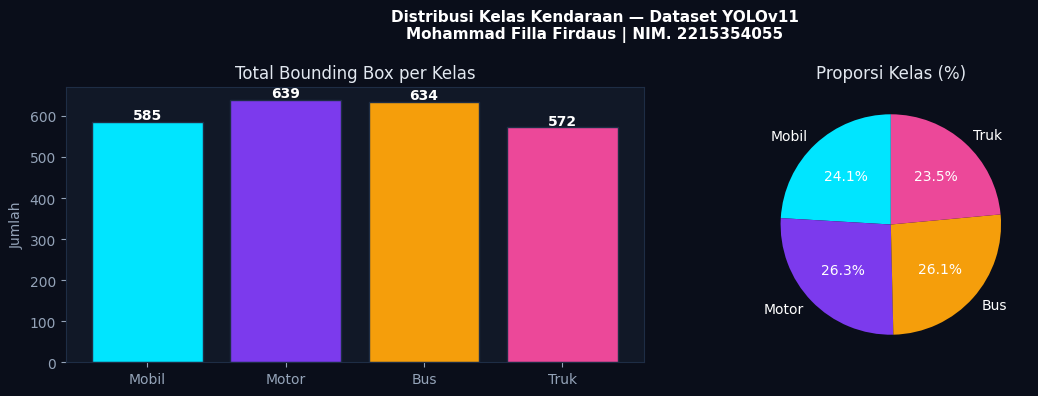

  [✓] Grafik disimpan: /kaggle/working/Skripsi_YOLOv11/logs/dataset_stats.png


In [75]:
# ──────────────────────────────────────────────────────────────
# [SEL-09] VERIFIKASI INTEGRITAS & STATISTIK DATASET
# ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

CLASS_COLORS = ['#00e5ff', '#7c3aed', '#f59e0b', '#ec4899']

def verify_and_stats(dataset_base):
    print("  " + "─"*50)
    print(f"  {'VERIFIKASI & STATISTIK DATASET':^50}")
    print("  " + "─"*50)

    all_counts = {i: 0 for i in range(NUM_CLASSES)}
    split_info = {}
    issues     = []

    for split in ["train", "valid", "test"]:
        img_dir = Path(dataset_base) / split / "images"
        lbl_dir = Path(dataset_base) / split / "labels"
        if not img_dir.exists():
            continue

        images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        labels = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
        counts = {i: 0 for i in range(NUM_CLASSES)}
        n_boxes = 0

        for lbl_f in labels:
            with open(lbl_f) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        try:
                            c = int(parts[0])
                            if 0 <= c < NUM_CLASSES:
                                counts[c]     += 1
                                all_counts[c] += 1
                                n_boxes       += 1
                        except ValueError:
                            issues.append(f"{lbl_f.name}: nilai tidak valid")

        split_info[split] = {"images": len(images), "labels": len(labels),
                              "boxes": n_boxes, "counts": counts}
        print(f"\n  Split: {split.upper()}")
        print(f"    Gambar : {len(images)} | Label : {len(labels)} | Box : {n_boxes}")
        for cid, cname in enumerate(CLASS_NAMES):
            pct = counts[cid] / n_boxes * 100 if n_boxes > 0 else 0
            bar = "█" * int(pct / 3)
            print(f"    {cname:<8}: {counts[cid]:5d} ({pct:5.1f}%) {bar}")

    # Cek imbalance
    total = sum(all_counts.values())
    if total > 0:
        vals = list(all_counts.values())
        ratio = max(vals) / (min(v for v in vals if v > 0) + 1e-9)
        print(f"\n  Rasio imbalance: {ratio:.1f}x")
        if ratio > 5:
            print("  ⚠️  Ketidakseimbangan kelas terdeteksi!")
            print("      Saran: tambah data Bus/Truk atau gunakan augmentasi")
        else:
            print("  [✓] Distribusi kelas seimbang")

    if issues:
        print(f"\n  ⚠️  Ditemukan {len(issues)} isu pada label")
    else:
        print("  [✓] Tidak ada isu pada format label")

    return split_info, all_counts

split_info, all_counts = verify_and_stats(DATASET_DIR)

# Visualisasi distribusi kelas
total = sum(all_counts.values())
if total > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0a0e1a')
    fig.suptitle("Distribusi Kelas Kendaraan — Dataset YOLOv11\n"
                 "Mohammad Filla Firdaus | NIM. 2215354055",
                 color='white', fontsize=11, fontweight='bold')

    for ax in axes:
        ax.set_facecolor('#111827')
        ax.tick_params(colors='#94a3b8')
        for sp in ax.spines.values():
            sp.set_edgecolor('#1e2d45')

    vals  = [all_counts[i] for i in range(NUM_CLASSES)]
    bars  = axes[0].bar(CLASS_NAMES, vals, color=CLASS_COLORS, edgecolor='#1e2d45')
    axes[0].set_title("Total Bounding Box per Kelas", color='#e2e8f0')
    axes[0].set_ylabel("Jumlah", color='#94a3b8')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(vals)*0.01,
                     str(v), ha='center', color='white', fontsize=10, fontweight='bold')

    pcts = [v/total*100 for v in vals]
    wedges, texts, autotexts = axes[1].pie(pcts, labels=CLASS_NAMES, autopct='%1.1f%%',
                                            colors=CLASS_COLORS, startangle=90,
                                            textprops={'color': 'white'})
    axes[1].set_title("Proporsi Kelas (%)", color='#e2e8f0')

    plt.tight_layout()
    chart_path = f"{DRIVE_PROJECT_DIR}/logs/dataset_stats.png"
    Path(f"{DRIVE_PROJECT_DIR}/logs").mkdir(exist_ok=True)
    plt.savefig(chart_path, dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print(f"  [✓] Grafik disimpan: {chart_path}")


---
## [SEL-10] 🤖 Load Model YOLOv11

In [76]:
# ──────────────────────────────────────────────────────────────
# [SEL-10] LOAD MODEL YOLOv11 PRETRAINED
# ──────────────────────────────────────────────────────────────
import torch
from ultralytics import YOLO

print("  [*] Mengunduh & memuat model YOLOv11...")
model = YOLO(MODEL_NAME)

# Info model
print(f"\n  [✓] Model        : {MODEL_NAME}")
print(f"  [✓] Task         : detection")

total_params    = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
print(f"  [✓] Total param  : {total_params:,}")
print(f"  [✓] Param latih  : {trainable_params:,}")
print(f"  [✓] GPU CUDA     : {'tersedia' if torch.cuda.is_available() else 'tidak tersedia'}")
if torch.cuda.is_available():
    print(f"  [✓] GPU Name     : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  [✓] VRAM        : {vram:.1f} GB")

print(f"\n  Model siap untuk training dengan {NUM_CLASSES} kelas kendaraan:")
for i, name in enumerate(CLASS_NAMES):
    print(f"    Class {i}: {name}")

  [*] Mengunduh & memuat model YOLOv11...

  [✓] Model        : yolo11s.pt
  [✓] Task         : detection
  [✓] Total param  : 9,458,752
  [✓] Param latih  : 0
  [✓] GPU CUDA     : tersedia
  [✓] GPU Name     : Tesla T4
  [✓] VRAM        : 15.6 GB

  Model siap untuk training dengan 4 kelas kendaraan:
    Class 0: Mobil
    Class 1: Motor
    Class 2: Bus
    Class 3: Truk


---
## [SEL-11] 🚀 TRAINING MODEL — Inti Proses

In [77]:
#
# [SEL-11] MULAI TRAINING YOLOv11 (DIPERBAIKI UNTUK mAP TINGGI)
#
import time
from datetime import datetime
import torch
import torch.nn as nn

# Cegah crash Ray Tune circular import di Kaggle/Colab
from ultralytics.utils import SETTINGS
SETTINGS["raytune"] = False

# CATATAN: callback pembeku BatchNorm DIHAPUS.
# Dengan freeze=0 (full fine-tune), BN HARUS ikut beradaptasi ke data baru.
# Membekukannya (pakai statistik COCO) bikin cls_loss macet & mAP ~nol.
# Batch >=8 sudah aman dari error "Expected more than 1 value per channel".

print("=" * 55)
print("  MEMULAI TRAINING YOLOv11 (FIXED CONFIG)")
print(f"  Mulai  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 55)

total_imgs = split_info.get("train", {}).get("images", 0)
gpu_name   = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"  Gambar training  : {total_imgs}")
print(f"  GPU              : {gpu_name}")
print("=" * 55)

start_time = time.time()

results = model.train(
    # Dataset
    data         = DATA_YAML_PATH,

    # Hyperparameter Utama
    epochs       = EPOCHS,
    batch        = BATCH_SIZE,
    imgsz        = IMG_SIZE,
    lr0          = LR0,
    lrf          = 0.01,
    optimizer    = OPTIMIZER,
    cos_lr       = True,

    # Hardware & Speed
    device       = DEVICE,        # Kaggle T4 x2 -> '0,1' (multi-GPU DDP otomatis)
    workers      = 4,
    cache        = True,

    # FULL FINE-TUNING: jangan bekukan layer (BN running-stats sudah dibekukan callback).
    freeze       = 0,

    # Regularisasi (cukup, tidak berlebihan)
    patience     = PATIENCE,
    weight_decay = 0.0005,
    warmup_epochs = 3.0,

    # Bobot Loss
    box          = 7.5,
    cls          = 0.5,     # default (lebih stabil)
    dfl          = 1.5,

    # Augmentasi - fokus objek kecil, hindari distorsi geometri berlebih
    mosaic       = 1.0,
    close_mosaic = 15,
    mixup        = 0.0,      # DIMATIKAN
    copy_paste   = 0.1,      # tambah variasi instance objek kecil
    multi_scale  = False,   # DIMATIKAN: di imgsz 960 bikin ukuran 1700-1900px -> OOM & tdk stabil
    fliplr       = 0.5,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    degrees      = 5.0,      # dikecilkan 10->5
    perspective  = 0.0,      # DIMATIKAN
    translate    = 0.1,
    scale        = 0.5,

    # CATATAN: JANGAN set conf/iou di sini. Validasi per-epoch (penentu best.pt)
    # WAJIB pakai conf default (~0.001) agar mAP dihitung benar.

    # Simpan & Output
    project      = RESULTS_DIR,
    name         = EXPERIMENT_NAME,
    exist_ok     = True,
    amp          = False,   # FP32 -> cegah NaN/overflow (FP16 sering meledak di config ini)
    save         = True,
    seed         = RANDOM_SEED,
)

elapsed = time.time() - start_time
RUN_DIR = Path(RESULTS_DIR) / EXPERIMENT_NAME
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"

print("\n" + "=" * 55)
print("   TRAINING SELESAI")
print("=" * 55)
print(f"  Durasi        : {elapsed/60:.1f} menit")
print(f"  Model terbaik : {BEST_PT}")
print(f"  Model terakhir: {LAST_PT}")
print(f"  Folder hasil  : {RUN_DIR}")


  MEMULAI TRAINING YOLOv11 (FIXED CONFIG)
  Mulai  : 2026-06-19 12:08:00
  Gambar training  : 437
  GPU              : Tesla T4
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Skripsi_YOLOv11/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0

---
## [SEL-12] 📊 Evaluasi Model Terbaik

In [78]:
# ------------------------------------------------------------
# [SEL-12] EVALUASI MODEL TERBAIK - METRIK LENGKAP (DIPERBAIKI)
# mAP DIHITUNG DENGAN conf=0.001 (benar), bukan 0.50.
# ------------------------------------------------------------
print("=" * 55)
print("  EVALUASI MODEL TERBAIK (best.pt) - proper mAP @ conf=0.001")
print("=" * 55)

if not BEST_PT.exists():
    print(f"  [!] best.pt tidak ditemukan, menggunakan last.pt")
    BEST_PT = LAST_PT

best_model = YOLO(str(BEST_PT))

val_results = best_model.val(
    data    = DATA_YAML_PATH,
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    conf    = VAL_CONF,   # 0.001 - kunci perbaikan
    iou     = VAL_IOU,
    device  = 0,   # validasi cukup 1 GPU (DDP tidak dipakai saat val)
    plots   = True,
    verbose = True,
    split   = 'val',
)

rd  = val_results.results_dict
P   = rd.get("metrics/precision(B)", 0)
R   = rd.get("metrics/recall(B)",    0)
M50 = rd.get("metrics/mAP50(B)",     0)
M95 = rd.get("metrics/mAP50-95(B)",  0)
F1  = 2 * P * R / (P + R + 1e-9)

print("\n  Metrik per-kelas:")
try:
    for idx, cid in enumerate(val_results.box.ap_class_index):
        name = CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else str(cid)
        p_c  = val_results.box.p[idx]
        r_c  = val_results.box.r[idx]
        ap50 = val_results.box.ap50[idx]
        print(f"    {name:<8}: P={p_c:.3f}  R={r_c:.3f}  mAP50={ap50:.3f}")
except Exception as e:
    print(f"    (tidak bisa menampilkan per-kelas: {e})")

print("\n  " + "-"*48)
print(f"  {'METRIK (Rumus 2.1-2.4 Proposal Skripsi)':^48}")
print("  " + "-"*48)
print(f"  {'Precision':<22}: {P:.4f}  (TP / (TP+FP))")
print(f"  {'Recall':<22}: {R:.4f}  (TP / (TP+FN))")
print(f"  {'F1-Score':<22}: {F1:.4f}  (2xPxR / (P+R))")
print(f"  {'mAP@50':<22}: {M50:.4f}  (rata-rata AP IoU=0.50)")
print(f"  {'mAP@50-95':<22}: {M95:.4f}  (rata-rata AP IoU=0.5..0.95)")
print("  " + "-"*48)

print("\n  Kriteria Penerimaan Model:")
if M50 >= 0.85:
    status = "SANGAT BAIK - Siap integrasi ke sistem Fuzzy"
elif M50 >= 0.80:
    status = "BAIK - Layak diintegrasikan ke Fuzzy Logic"
elif M50 >= 0.70:
    status = "CUKUP - Pertimbangkan fine-tuning lebih lanjut"
else:
    status = "KURANG - Perlu lebih banyak data dan epoch"
print(f"  mAP@50 = {M50:.4f} -> {status}")

import json
metrics_dict = {
    "timestamp"  : datetime.now().isoformat(),
    "model"      : MODEL_NAME,
    "experiment" : EXPERIMENT_NAME,
    "eval_conf"  : VAL_CONF,
    "hyperparams": {"epochs": EPOCHS, "batch": BATCH_SIZE, "lr0": LR0, "optimizer": OPTIMIZER},
    "metrics"    : {"precision": round(P,4), "recall": round(R,4), "f1": round(F1,4),
                    "mAP50": round(M50,4), "mAP50_95": round(M95,4)},
    "mahasiswa"  : "Mohammad Filla Firdaus",
    "nim"        : "2215354055",
}
log_path = f"{DRIVE_PROJECT_DIR}/logs/metrics_{EXPERIMENT_NAME}.json"
with open(log_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print(f"\n  [OK] Metrik disimpan: {log_path}")


  EVALUASI MODEL TERBAIK (best.pt) - proper mAP @ conf=0.001
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1937.3±232.1 MB/s, size: 193.3 KB)
val: Scanning /kaggle/working/Skripsi_YOLOv11/dataset/valid/labels.cache... 125 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 125/125 58.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.8it/s 3.4s0.2s
                   all        125        549      0.767      0.658      0.692      0.508
                   bus        100        115      0.852      0.887      0.929      0.759
                   car          6        114      0.896      0.833      0.895      0.651
            motorcycle         15        200      0.733      0.261      0.281      0.127
                 truck         23        120 

---
## [SEL-13] 📈 Grafik Hasil Training

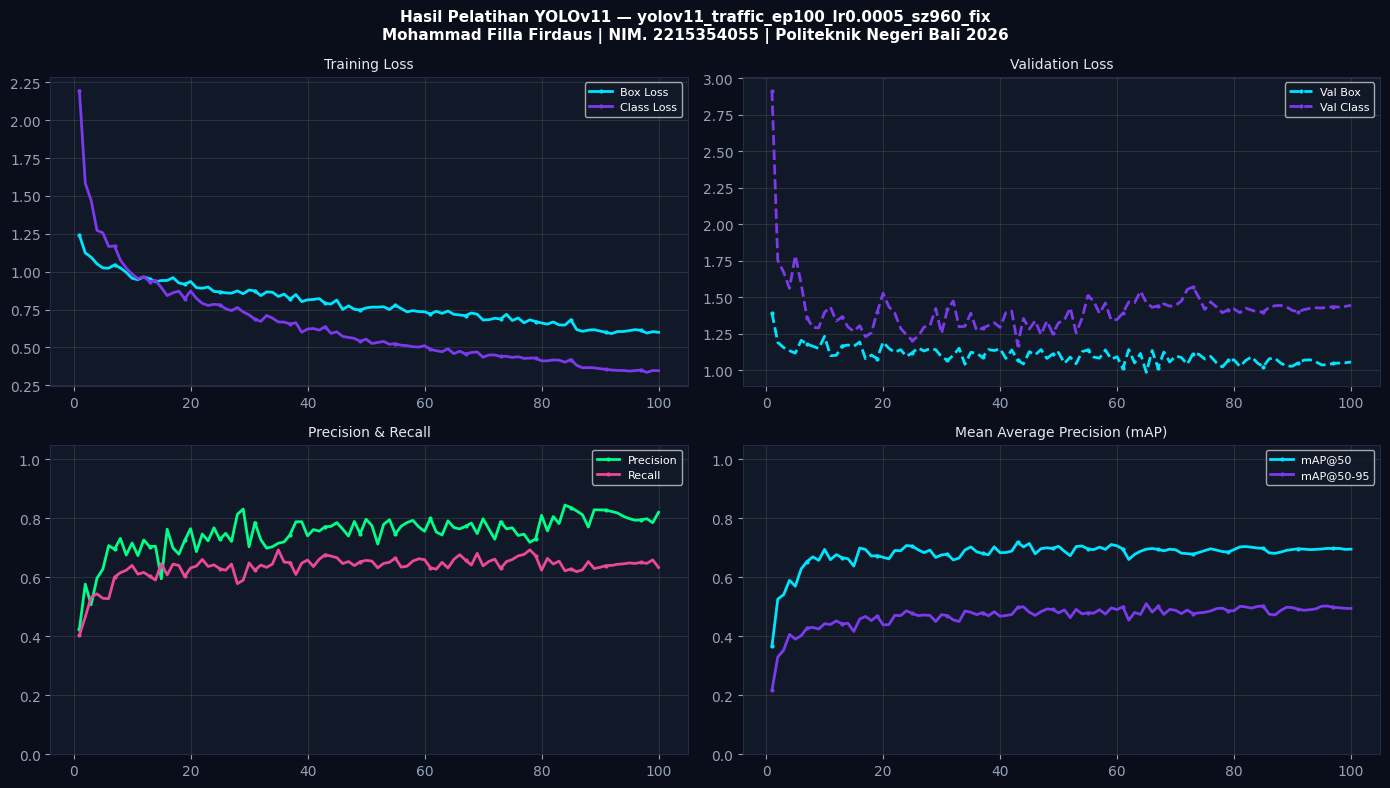

  [✓] Grafik disimpan: /kaggle/working/Skripsi_YOLOv11/logs/training_curves_yolov11_traffic_ep100_lr0.0005_sz960_fix.png

  Confusion Matrix:


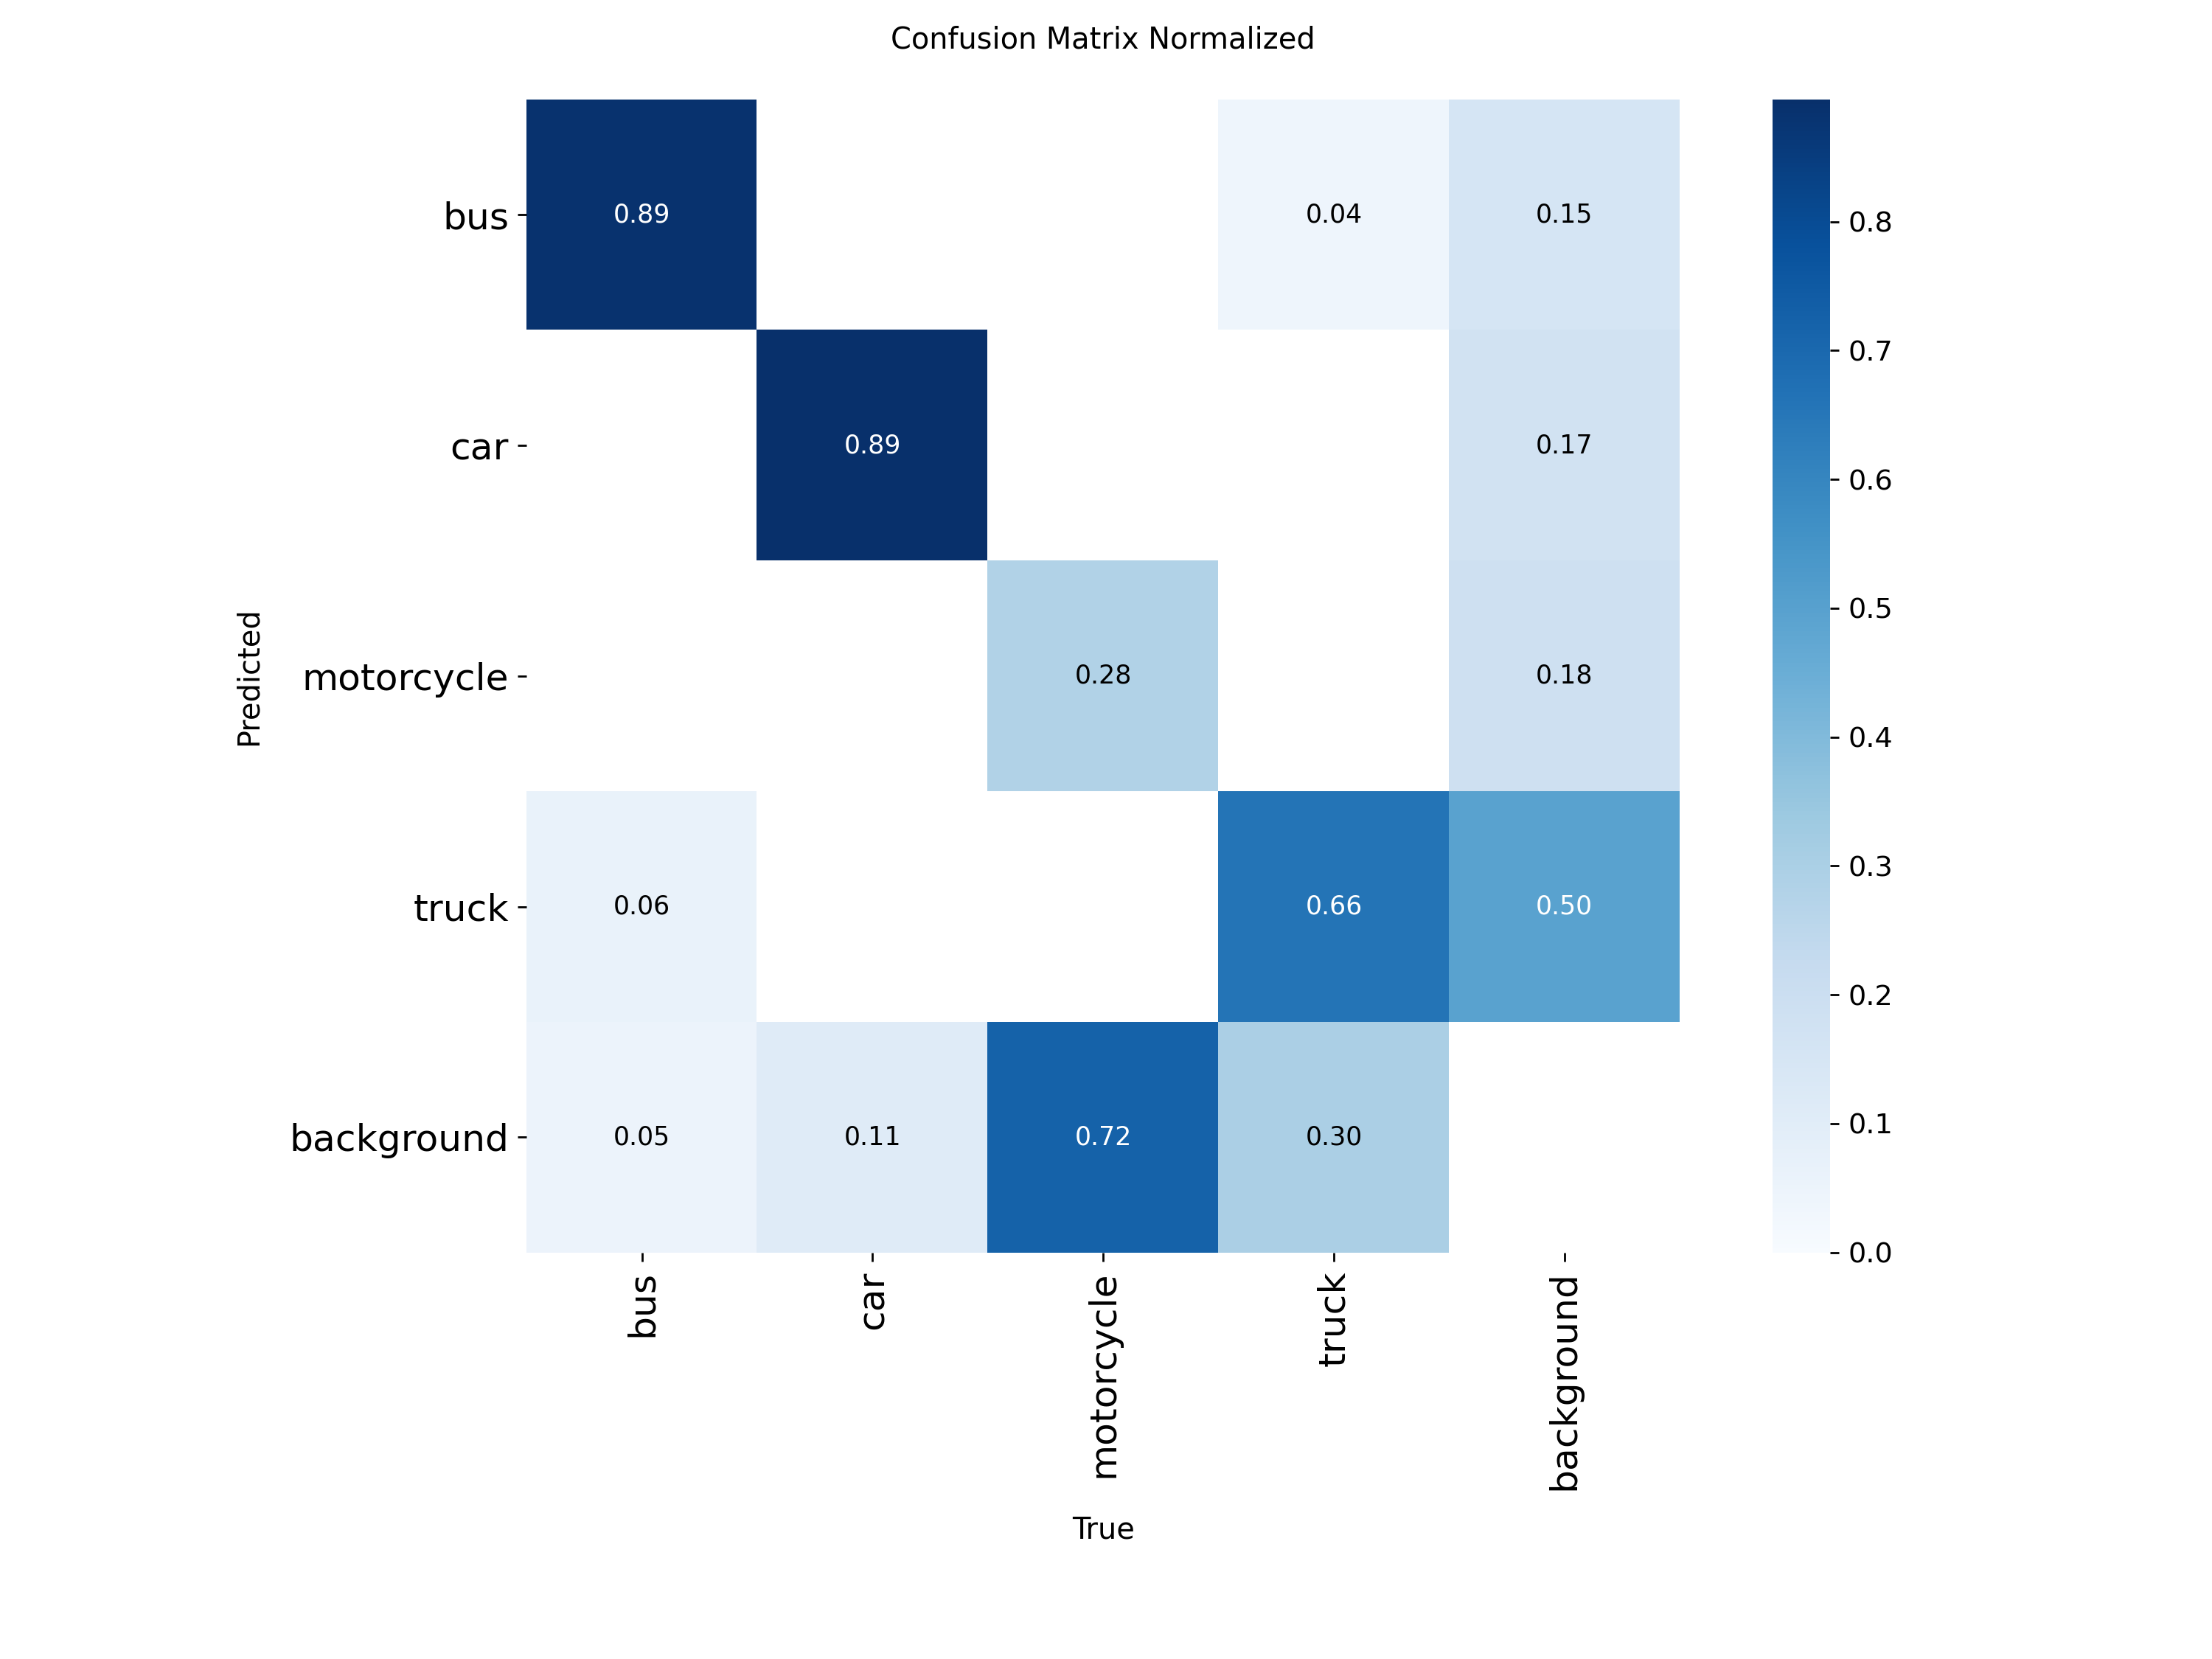

In [79]:
# ──────────────────────────────────────────────────────────────
# [SEL-13] TAMPILKAN GRAFIK HASIL TRAINING
# ──────────────────────────────────────────────────────────────
import csv
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

results_csv = RUN_DIR / "results.csv"

if results_csv.exists():
    epochs_list, box_loss, cls_loss = [], [], []
    val_box, val_cls = [], []
    prec_list, rec_list, map50_list, map95_list = [], [], [], []

    with open(results_csv) as f:
        reader = csv.DictReader(f)
        for row in reader:
            def g(k):
                v = row.get(k, "").strip()
                return float(v) if v else None
            ep = g("epoch")
            if ep is None: continue
            epochs_list.append(int(ep))
            box_loss.append(g("train/box_loss"))
            cls_loss.append(g("train/cls_loss"))
            val_box.append(g("val/box_loss"))
            val_cls.append(g("val/cls_loss"))
            prec_list.append(g("metrics/precision(B)"))
            rec_list.append(g("metrics/recall(B)"))
            map50_list.append(g("metrics/mAP50(B)"))
            map95_list.append(g("metrics/mAP50-95(B)"))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor='#0a0e1a')
    fig.suptitle(
        f"Hasil Pelatihan YOLOv11 — {EXPERIMENT_NAME}\n"
        "Mohammad Filla Firdaus | NIM. 2215354055 | Politeknik Negeri Bali 2026",
        color='white', fontsize=11, fontweight='bold'
    )

    PLOT_STYLE = {'facecolor': '#111827', 'spines': '#1e2d45', 'tick': '#94a3b8'}

    def style_ax(ax, title):
        ax.set_facecolor(PLOT_STYLE['facecolor'])
        ax.tick_params(colors=PLOT_STYLE['tick'])
        ax.xaxis.label.set_color(PLOT_STYLE['tick'])
        ax.yaxis.label.set_color(PLOT_STYLE['tick'])
        ax.set_title(title, color='#e2e8f0', fontsize=10)
        ax.grid(True, alpha=0.15)
        for sp in ax.spines.values(): sp.set_edgecolor(PLOT_STYLE['spines'])

    def safe_plot(ax, x, y, label, color, ls='-', lw=2):
        data = [(xi, yi) for xi, yi in zip(x, y) if yi is not None]
        if data:
            xs, ys = zip(*data)
            ax.plot(xs, ys, color=color, label=label, linewidth=lw,
                    linestyle=ls, marker='o', markersize=2,
                    markevery=max(1, len(xs)//15))

    # Plot 1: Training Loss
    safe_plot(axes[0,0], epochs_list, box_loss, "Box Loss",   "#00e5ff")
    safe_plot(axes[0,0], epochs_list, cls_loss, "Class Loss", "#7c3aed")
    axes[0,0].legend(fontsize=8, facecolor='#111827', labelcolor='white')
    style_ax(axes[0,0], "Training Loss")

    # Plot 2: Validation Loss
    safe_plot(axes[0,1], epochs_list, val_box, "Val Box",  "#00e5ff", '--')
    safe_plot(axes[0,1], epochs_list, val_cls, "Val Class", "#7c3aed", '--')
    axes[0,1].legend(fontsize=8, facecolor='#111827', labelcolor='white')
    style_ax(axes[0,1], "Validation Loss")

    # Plot 3: Precision & Recall
    safe_plot(axes[1,0], epochs_list, prec_list, "Precision", "#00ff88")
    safe_plot(axes[1,0], epochs_list, rec_list,  "Recall",    "#ec4899")
    axes[1,0].set_ylim(0, 1.05)
    axes[1,0].legend(fontsize=8, facecolor='#111827', labelcolor='white')
    style_ax(axes[1,0], "Precision & Recall")

    # Plot 4: mAP
    safe_plot(axes[1,1], epochs_list, map50_list,  "mAP@50",    "#00e5ff")
    safe_plot(axes[1,1], epochs_list, map95_list,  "mAP@50-95", "#7c3aed")
    axes[1,1].set_ylim(0, 1.05)
    axes[1,1].legend(fontsize=8, facecolor='#111827', labelcolor='white')
    style_ax(axes[1,1], "Mean Average Precision (mAP)")

    plt.tight_layout()
    chart_out = f"{DRIVE_PROJECT_DIR}/logs/training_curves_{EXPERIMENT_NAME}.png"
    plt.savefig(chart_out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print(f"  [✓] Grafik disimpan: {chart_out}")

# Tampilkan Confusion Matrix dari Ultralytics
cm_path = RUN_DIR / "confusion_matrix_normalized.png"
if cm_path.exists():
    print("\n  Confusion Matrix:")
    display(IPImage(str(cm_path)))

# PR Curve
pr_path = RUN_DIR / "PR_curve.png"
if pr_path.exists():
    print("\n  Precision-Recall Curve:")
    display(IPImage(str(pr_path)))

---
## [SEL-14] 🔎 Inferensi pada Gambar/Video Uji

  [!] Tidak ada gambar uji. Membuat gambar dummy untuk demo...
  [*] Inferensi pada 1 gambar uji...


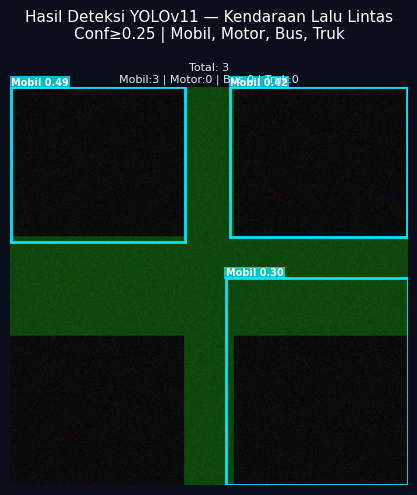

  [✓] Hasil inferensi disimpan: /kaggle/working/Skripsi_YOLOv11/logs/inference_sample.png


In [80]:
# ──────────────────────────────────────────────────────────────
# [SEL-14] INFERENSI PADA GAMBAR UJI
# Lihat hasil deteksi bounding box + confidence score
# ──────────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import Image as IPImage, display
import glob

CLASS_COLORS_RGB = [
    (0, 229, 255),    # Mobil  — cyan
    (124, 58, 237),   # Motor  — ungu
    (245, 158, 11),   # Bus    — kuning
    (236, 72, 153),   # Truk   — pink
]

# Cari gambar uji di folder val
test_imgs = (glob.glob(f"{DATASET_DIR}/images/val/*.jpg") +
             glob.glob(f"{DATASET_DIR}/images/test/*.jpg"))

if not test_imgs:
    print("  [!] Tidak ada gambar uji. Membuat gambar dummy untuk demo...")
    # Buat gambar demo
    demo_img = np.zeros((640, 640, 3), dtype=np.uint8)
    demo_img[240:400, :, 1] = 60
    demo_img[:, 280:360, 1] = 60
    noise = np.random.randint(0, 25, (640, 640, 3), dtype=np.uint8)
    demo_img = np.clip(demo_img.astype(int) + noise, 0, 255).astype(np.uint8)
    demo_path = "/content/demo_test.jpg"
    cv2.imwrite(demo_path, demo_img)
    test_imgs = [demo_path]

# Inferensi pada beberapa gambar contoh
N_SHOW  = min(4, len(test_imgs))
samples = test_imgs[:N_SHOW]

print(f"  [*] Inferensi pada {N_SHOW} gambar uji...")
results_list = best_model.predict(
    source = samples,
    imgsz  = IMG_SIZE,
    conf   = CONF_THRESHOLD,
    iou    = IOU_THRESHOLD,
    device = 0 if torch.cuda.is_available() else 'cpu',
    verbose= False,
)

# Visualisasi
fig, axes = plt.subplots(1, N_SHOW, figsize=(5 * N_SHOW, 5), facecolor='#0a0e1a')
if N_SHOW == 1:
    axes = [axes]

fig.suptitle("Hasil Deteksi YOLOv11 — Kendaraan Lalu Lintas\n"
             f"Conf≥{CONF_THRESHOLD} | {', '.join(CLASS_NAMES)}",
             color='white', fontsize=11)

for ax, result, img_path in zip(axes, results_list, samples):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_facecolor('#111827')
    ax.axis('off')

    counts = {i: 0 for i in range(NUM_CLASSES)}
    for box in result.boxes:
        cls_id       = int(box.cls[0])
        conf_score   = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        color        = [c/255 for c in CLASS_COLORS_RGB[cls_id]]
        label        = f"{CLASS_NAMES[cls_id]} {conf_score:.2f}"
        counts[cls_id] += 1

        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 3, label, color='white', fontsize=7, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor='none'))

    total = sum(counts.values())
    info  = f"Total: {total}\n" + " | ".join(f"{CLASS_NAMES[i]}:{counts[i]}" for i in range(NUM_CLASSES))
    ax.set_title(info, color='#e2e8f0', fontsize=8, pad=3)

plt.tight_layout()
inf_out = f"{DRIVE_PROJECT_DIR}/logs/inference_sample.png"
plt.savefig(inf_out, dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print(f"  [✓] Hasil inferensi disimpan: {inf_out}")

In [81]:
# ──────────────────────────────────────────────────────────────
# [SEL-14B] BENCHMARK LATENCY INFERENSI
# Sesuai Tabel 3.11 Pengujian Kinerja Sistem — Proposal
# ──────────────────────────────────────────────────────────────
import time
import numpy as np

print("═" * 50)
print("  BENCHMARK LATENSI INFERENSI YOLOv11")
print("  Sesuai Tabel 3.11 Proposal Skripsi")
print("═" * 50)

# Buat frame dummy 640×640
dummy_frame = np.random.randint(50, 100, (640, 640, 3), dtype=np.uint8)
N_RUNS      = 30
latencies   = []

# Warmup
for _ in range(3):
    best_model.predict(dummy_frame, imgsz=IMG_SIZE, conf=CONF_THRESHOLD,
                       verbose=False)

# Benchmark
for i in range(N_RUNS):
    t0 = time.perf_counter()
    best_model.predict(dummy_frame, imgsz=IMG_SIZE, conf=CONF_THRESHOLD,
                       device=0 if torch.cuda.is_available() else 'cpu',
                       verbose=False)
    latencies.append((time.perf_counter() - t0) * 1000)

avg_lat = np.mean(latencies)
min_lat = np.min(latencies)
max_lat = np.max(latencies)
fps_eff = 1000 / avg_lat

print(f"\n  {'Metrik':<25} {'Nilai':<15} {'Target':<15}")
print("  " + "─"*55)
print(f"  {'Avg Latency':<25} {avg_lat:>8.1f} ms    {'< 100 ms':<15}")
print(f"  {'Min Latency':<25} {min_lat:>8.1f} ms")
print(f"  {'Max Latency':<25} {max_lat:>8.1f} ms")
print(f"  {'Effective FPS':<25} {fps_eff:>8.1f} FPS    {'> 10 FPS':<15}")
print(f"  {'GPU':<25} {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print("  " + "─"*55)

status_lat = "✅ Real-time" if avg_lat < 100 else "⚠️  Terlalu lambat"
status_fps = "✅ Real-time" if fps_eff > 10  else "⚠️  FPS rendah"
print(f"  Latensi : {status_lat}")
print(f"  FPS     : {status_fps}")

══════════════════════════════════════════════════
  BENCHMARK LATENSI INFERENSI YOLOv11
  Sesuai Tabel 3.11 Proposal Skripsi
══════════════════════════════════════════════════

  Metrik                    Nilai           Target         
  ───────────────────────────────────────────────────────
  Avg Latency                   25.6 ms    < 100 ms       
  Min Latency                   22.9 ms
  Max Latency                   32.7 ms
  Effective FPS                 39.0 FPS    > 10 FPS       
  GPU                       CUDA
  ───────────────────────────────────────────────────────
  Latensi : ✅ Real-time
  FPS     : ✅ Real-time


---
## [SEL-15] 📦 Ekspor Model ke ONNX

In [82]:
# ──────────────────────────────────────────────────────────────
# [SEL-15] EKSPOR MODEL KE FORMAT ONNX
# Format ONNX digunakan untuk integrasi ke FastAPI Backend
# ──────────────────────────────────────────────────────────────
print("  [*] Mengekspor model ke ONNX...")
print("      (format ini digunakan oleh FastAPI Backend sistem)")

try:
    exported_path = best_model.export(
        format   = "onnx",
        imgsz    = IMG_SIZE,
        dynamic  = False,
        simplify = True,
        opset    = 12,
    )
    print(f"  [✓] ONNX tersimpan : {exported_path}")

    # Salin ke folder exports di Drive
    import shutil
    export_dest = f"{DRIVE_PROJECT_DIR}/exports/{EXPERIMENT_NAME}.onnx"
    shutil.copy2(exported_path, export_dest)
    print(f"  [✓] Disalin ke     : {export_dest}")

except Exception as e:
    print(f"  [!] Gagal ekspor ONNX: {e}")
    print("      Pastikan onnx dan onnxsim terinstall:")
    print("      !pip install onnx onnxsim")

  [*] Mengekspor model ke ONNX...
      (format ini digunakan oleh FastAPI Backend sistem)
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/Skripsi_YOLOv11/runs/yolov11_traffic_ep100_lr0.0005_sz960_fix/weights/best.pt' with input shape (1, 3, 960, 960) BCHW and output shape(s) (1, 8, 18900) (18.4 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 238ms
Prepared 2 packages in 287ms
Installed 2 packages in 24ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming 

---
## [SEL-16] 💾 Simpan Semua Hasil ke Google Drive

In [83]:
# 
# [SEL-16] SIMPAN HASIL & AMBIL MODEL DENGAN METRIK TERINGGI (mAP@50)
# 
import shutil
from pathlib import Path
import glob
import json
from datetime import datetime

print("=" * 55)
print("  MENYIMPAN SEMUA HASIL KE GOOGLE DRIVE")
print("=" * 55)

# 1. Salin folder weights saat ini ke Drive
weights_dest = f"{DRIVE_PROJECT_DIR}/best_weights/{EXPERIMENT_NAME}"
weights_src  = RUN_DIR / "weights"

if weights_src.exists():
    Path(weights_dest).mkdir(parents=True, exist_ok=True)
    for wf in weights_src.iterdir():
        shutil.copy2(wf, Path(weights_dest) / wf.name)
    print(f"  [✓] Folder weights berhasil disalin ke: {weights_dest}")

# 2. Salin grafik hasil training (plots Ultralytics)
plots_to_copy = [
    "confusion_matrix.png", "confusion_matrix_normalized.png",
    "PR_curve.png", "F1_curve.png", "results.png", "results.csv"
]
log_dir = Path(f"{DRIVE_PROJECT_DIR}/logs")
log_dir.mkdir(exist_ok=True)

for fname in plots_to_copy:
    src = RUN_DIR / fname
    if src.exists():
        shutil.copy2(src, log_dir / f"{EXPERIMENT_NAME}_{fname}")
        print(f"  [✓] {fname} berhasil disalin")

# 3. 🔍 MENCARI DAN MENGAMBIL MODEL DENGAN mAP@50 TERTINGGI (BEST MODEL SELECTION)
print("\n" + "=" * 55)
print("  EVALUASI DAN PEMILIHAN MODEL HASIL TERTINGGI")
print("=" * 55)

log_files = glob.glob(f"{DRIVE_PROJECT_DIR}/logs/metrics_*.json")

if not log_files:
    print("  [!] Belum ada log metrik di folder logs/ untuk dievaluasi.")
    # Jika tidak ada log, salin model dari run saat ini saja ke root project
    if BEST_PT.exists():
        dest_main = Path(DRIVE_PROJECT_DIR) / "best.pt"
        shutil.copy2(BEST_PT, dest_main)
        print(f"  [✓] Menyalin model run saat ini ke root Drive: {dest_main}")
else:
    best_map = -1.0
    best_run_name = ""
    
    print("  Daftar Riwayat Eksperimen:")
    print(f"  {'Nama Eksperimen':<38} | {'mAP@50':^10}")
    print("  " + "-" * 52)
    
    for lf in log_files:
        try:
            with open(lf, "r", encoding="utf-8") as f:
                log_data = json.load(f)
                exp_name = log_data.get("experiment", "unknown")
                map50 = log_data.get("metrics", {}).get("mAP50", 0.0)
                print(f"  {exp_name:<38} | {map50:^10.4f}")
                
                if map50 > best_map:
                    best_map = map50
                    best_run_name = exp_name
        except Exception as e:
            pass
            
    print("  " + "-" * 52)
    print(f"  [★] Eksperimen Terbaik: {best_run_name} (mAP@50: {best_map:.4f})")
    
    # Path model terbaik dari runs lokal
    best_weights_path = Path(RESULTS_DIR) / best_run_name / "weights" / "best.pt"
    # Fallback ke folder best_weights di Drive jika folder runs lokal telah dihapus
    best_weights_drive = Path(DRIVE_PROJECT_DIR) / "best_weights" / best_run_name / "best.pt"
    
    dest_main = Path(DRIVE_PROJECT_DIR) / "best.pt"
    
    copied = False
    if best_weights_path.exists():
        shutil.copy2(best_weights_path, dest_main)
        copied = True
    elif best_weights_drive.exists():
        shutil.copy2(best_weights_drive, dest_main)
        copied = True
        
    if copied:
        print(f"  [✓] Model hasil tertinggi berhasil disalin ke: {dest_main}")
        
        # Ekspor juga versi ONNX-nya jika ada
        best_onnx_path = Path(RESULTS_DIR) / best_run_name / "weights" / "best.onnx"
        best_onnx_drive = Path(DRIVE_PROJECT_DIR) / "best_weights" / best_run_name / "best.onnx"
        dest_onnx = Path(DRIVE_PROJECT_DIR) / "best.onnx"
        
        if best_onnx_path.exists():
            shutil.copy2(best_onnx_path, dest_onnx)
            print(f"  [✓] Model ONNX hasil tertinggi disalin ke: {dest_onnx}")
        elif best_onnx_drive.exists():
            shutil.copy2(best_onnx_drive, dest_onnx)
            print(f"  [✓] Model ONNX hasil tertinggi disalin ke: {dest_onnx}")
    else:
        print("  [!] Gagal menyalin model terbaik. File model tidak ditemukan.")

print("\n" + "=" * 55)
print("   SEMUA PROSES SELESAI!")
print("=" * 55)
print(f"  Folder Project  : {DRIVE_PROJECT_DIR}")
print(f"  Model Utama     : {DRIVE_PROJECT_DIR}/best.pt  (Otomatis versi tertinggi!)")
print(f"  Model ONNX Utama: {DRIVE_PROJECT_DIR}/best.onnx (Otomatis versi tertinggi!)")
print(f"  mAP@50 Tertinggi: {best_map:.4f}" if 'best_map' in locals() else "")
print("=" * 55)


  MENYIMPAN SEMUA HASIL KE GOOGLE DRIVE
  [✓] Folder weights berhasil disalin ke: /kaggle/working/Skripsi_YOLOv11/best_weights/yolov11_traffic_ep100_lr0.0005_sz960_fix
  [✓] confusion_matrix.png berhasil disalin
  [✓] confusion_matrix_normalized.png berhasil disalin
  [✓] results.png berhasil disalin
  [✓] results.csv berhasil disalin

  EVALUASI DAN PEMILIHAN MODEL HASIL TERTINGGI
  Daftar Riwayat Eksperimen:
  Nama Eksperimen                        |   mAP@50  
  ----------------------------------------------------
  yolov11_traffic_ep100_lr0.0005_sz960_fix |   0.6923  
  ----------------------------------------------------
  [★] Eksperimen Terbaik: yolov11_traffic_ep100_lr0.0005_sz960_fix (mAP@50: 0.6923)
  [✓] Model hasil tertinggi berhasil disalin ke: /kaggle/working/Skripsi_YOLOv11/best.pt
  [✓] Model ONNX hasil tertinggi disalin ke: /kaggle/working/Skripsi_YOLOv11/best.onnx

   SEMUA PROSES SELESAI!
  Folder Project  : /kaggle/working/Skripsi_YOLOv11
  Model Utama     : /kaggle/

In [84]:
from google.colab import drive
drive.mount('/content/drive')

NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

In [87]:
  import os, shutil
  from datetime import datetime
  from pathlib import Path

  IN_COLAB  = os.path.exists('/var/colab/hostname')
  IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

  stamp        = datetime.now().strftime('%Y%m%d_%H%M%S')
  archive_base = f"HASIL_{EXPERIMENT_NAME}_{stamp}"
  export_root  = Path(DRIVE_PROJECT_DIR) / "_export"
  stage        = export_root / archive_base
  stage.mkdir(parents=True, exist_ok=True)

  if RUN_DIR.exists():
      shutil.copytree(RUN_DIR, stage / "run", dirs_exist_ok=True)

  logs_dir = Path(DRIVE_PROJECT_DIR) / "logs"
  if logs_dir.exists():
      shutil.copytree(logs_dir, stage / "logs", dirs_exist_ok=True)

  if Path(DATA_YAML_PATH).exists():
      shutil.copy(DATA_YAML_PATH, stage / "data.yaml")

  zip_path = shutil.make_archive(str(export_root / archive_base), 'zip', root_dir=str(stage))
  print(f"[OK] ZIP dibuat ({os.path.getsize(zip_path)/1e6:.1f} MB): {zip_path}")

  if IN_COLAB:
      out = Path("/content/drive/MyDrive/Skripsi_YOLOv11_HASIL")
      out.mkdir(parents=True, exist_ok=True)
      shutil.copy(zip_path, out / Path(zip_path).name)
      print("Tersimpan di Google Drive:", out / Path(zip_path).name)
  elif IN_KAGGLE:
      final = Path("/kaggle/working") / Path(zip_path).name
      if str(final) != str(zip_path):
          shutil.copy(zip_path, final)
      print("ZIP siap diunduh dari panel OUTPUT Kaggle:", final)
      print("Lalu upload file ZIP itu ke Google Drive-mu.")

[OK] ZIP dibuat (76.7 MB): /kaggle/working/Skripsi_YOLOv11/_export/HASIL_yolov11_traffic_ep100_lr0.0005_sz960_fix_20260619_135420.zip
ZIP siap diunduh dari panel OUTPUT Kaggle: /kaggle/working/HASIL_yolov11_traffic_ep100_lr0.0005_sz960_fix_20260619_135420.zip
Lalu upload file ZIP itu ke Google Drive-mu.


In [90]:
  import os, shutil
  from datetime import datetime
  from pathlib import Path

  IN_COLAB  = os.path.exists('/var/colab/hostname')
  IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

  stamp        = datetime.now().strftime('%Y%m%d_%H%M%S')
  archive_base = f"HASIL_{EXPERIMENT_NAME}_{stamp}"

  print("=" * 55)
  print("  MENGEMAS SEMUA HASIL TRAINING")
  print("=" * 55)

  # 1) Kumpulkan semua artefak ke satu folder staging --------------
  export_root = Path(DRIVE_PROJECT_DIR) / "_export"
  stage       = export_root / archive_base
  stage.mkdir(parents=True, exist_ok=True)

  # a. Seluruh folder run: weights/best.pt, last.pt, results.csv, args.yaml,
  #    confusion_matrix*.png, PR_curve.png, F1_curve.png, val_batch*.jpg, dll.
  if RUN_DIR.exists():
      shutil.copytree(RUN_DIR, stage / "run", dirs_exist_ok=True)
      print(f"  [OK] Folder run disalin   : {RUN_DIR}")
  else:
      print(f"  [!] RUN_DIR tidak ditemukan: {RUN_DIR}")

  # b. Folder logs (metrik JSON + grafik buatan SEL-12/SEL-13)
  logs_dir = Path(DRIVE_PROJECT_DIR) / "logs"
  if logs_dir.exists():
      shutil.copytree(logs_dir, stage / "logs", dirs_exist_ok=True)
      print(f"  [OK] Folder logs disalin  : {logs_dir}")

  # c. data.yaml (konfigurasi dataset)
  try:
      if Path(DATA_YAML_PATH).exists():
          shutil.copy(DATA_YAML_PATH, stage / "data.yaml")
          print(f"  [OK] data.yaml disalin")
  except NameError:
      pass

  # 2) Buat ZIP ----------------------------------------------------
  zip_path = shutil.make_archive(str(export_root / archive_base), 'zip', root_dir=str(stage))
  zip_mb   = os.path.getsize(zip_path) / 1e6
  print(f"\n  [OK] ZIP dibuat ({zip_mb:.1f} MB):\n       {zip_path}")

  # 3) Tujuan akhir per-lingkungan ---------------------------------
  if IN_COLAB:
      # Colab: salin ZIP ke Google Drive yang sudah di-mount (lihat SEL-03)
      drive_out = Path("/content/drive/MyDrive/Skripsi_YOLOv11_HASIL")
      drive_out.mkdir(parents=True, exist_ok=True)
      final = drive_out / Path(zip_path).name
      shutil.copy(zip_path, final)
      print("\n  [OK] HASIL TERSIMPAN DI GOOGLE DRIVE:")
      print(f"       {final}")
  else:
      # Kaggle / lokal: salin ZIP ke /kaggle/working agar mudah diunduh dari Output
      if IN_KAGGLE:
          final = Path("/kaggle/working") / Path(zip_path).name
          if str(final) != str(zip_path):
              shutil.copy(zip_path, final)
          print("\n  [OK] ZIP siap diunduh dari panel OUTPUT Kaggle:")
          print(f"       {final}")
      print("\n  ---------------------------------------------------------")
      print("  CARA SIMPAN KE GOOGLE DRIVE (Kaggle):")
      print("  1. Buka panel kanan 'Output' -> cari file ZIP di atas")
      print("  2. Klik titik tiga (...) -> Download")
      print("  3. Upload file ZIP itu ke Google Drive milikmu")
      print("  ---------------------------------------------------------")

  # Ringkas isi paket terpenting
  best = RUN_DIR / "weights" / "best.pt"
  last = RUN_DIR / "weights" / "last.pt"
  print("\n  Isi penting paket:")
  print(f"    - best.pt  : {'ADA' if best.exists() else 'tidak ada'}")
  print(f"    - last.pt  : {'ADA' if last.exists() else 'tidak ada'}")
  print(f"    - results.csv, confusion_matrix.png, PR_curve.png, grafik training, metrik JSON")
  print("=" * 55)

  Kalau mau upload OTOMATIS ke Google Drive dari Kaggle (opsional)

  Tambahkan sel terpisah ini dan jalankan setelah sel di atas:

  # Upload otomatis ZIP ke Google Drive (sekali setup OAuth)
  !pip install -q pydrive2
  from pydrive2.auth import GoogleAuth
  from pydrive2.drive import GoogleDrive
  from pathlib import Path

  gauth = GoogleAuth()
  gauth.CommandLineAuth()            # muncul link -> buka -> tempel kode verifikasi di sini
  drive = GoogleDrive(gauth)

  f = drive.CreateFile({'title': Path(zip_path).name})
  f.SetContentFile(zip_path)
  f.Upload()
  print("Terupload ke Google Drive:", f['title'])

SyntaxError: invalid syntax (3292236156.py, line 80)